In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,RobustScaler,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [27]:
df=pd.read_csv('/content/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [28]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


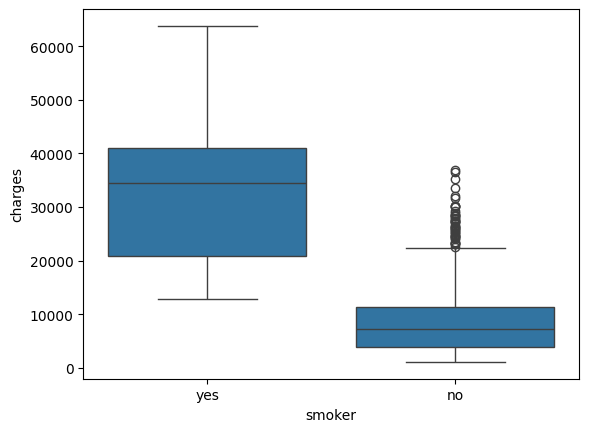

In [30]:
sns.boxplot(x='smoker',y='charges',data=df)
plt.show()

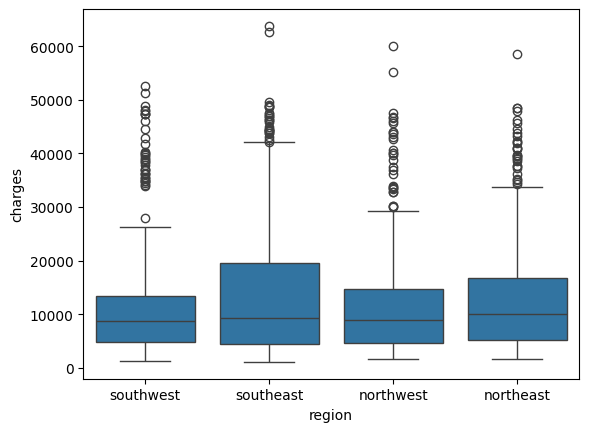

In [31]:
sns.boxplot(x='region',y='charges',data=df)
plt.show()

In [32]:
num_cols=list(df.select_dtypes(include='number').columns)
num_cols

['age', 'bmi', 'children', 'charges']

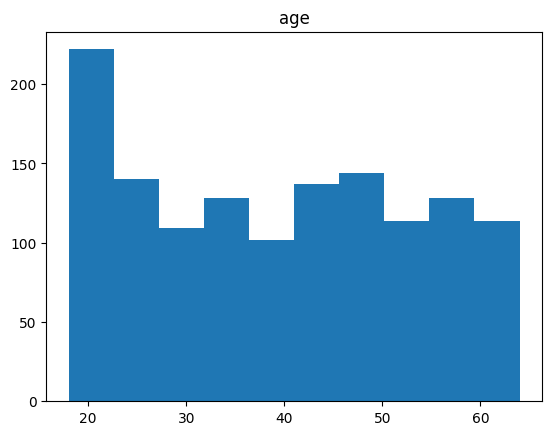

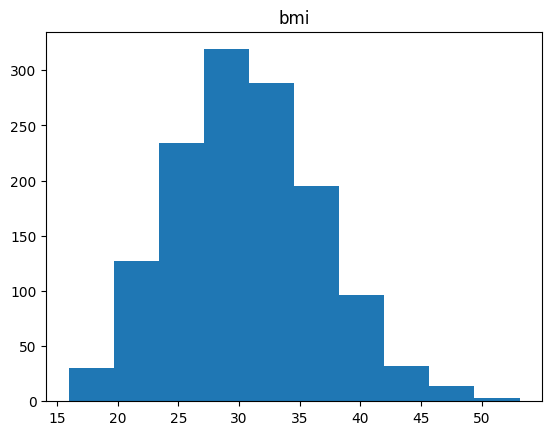

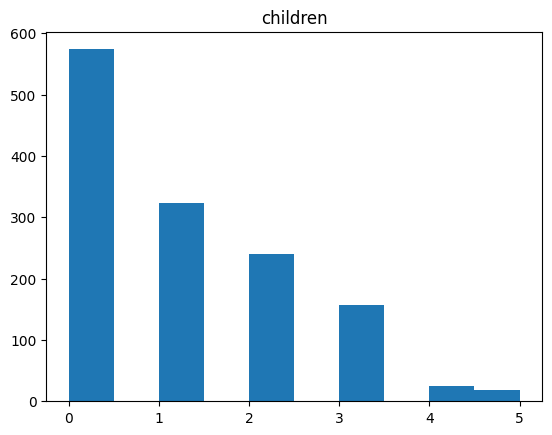

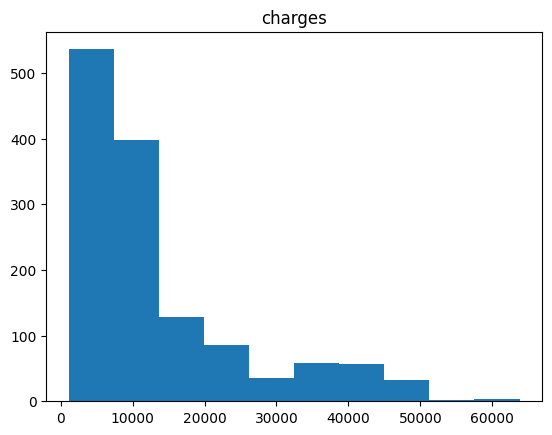

In [33]:
for col in num_cols:
  plt.hist(df[col])
  plt.title(col)
  plt.show()

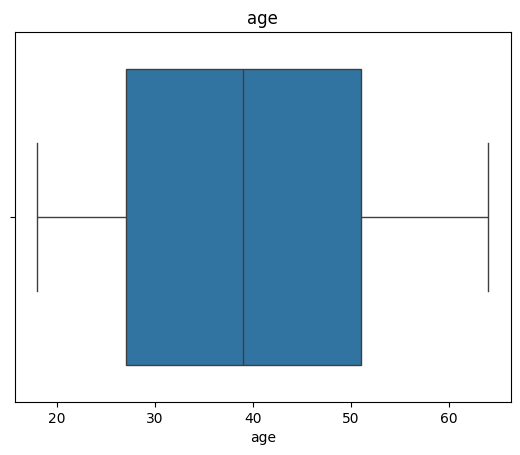

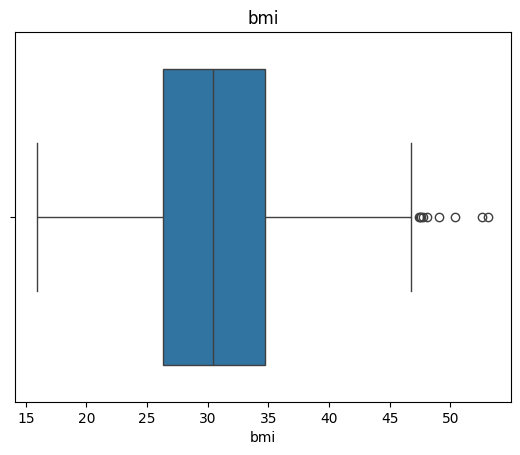

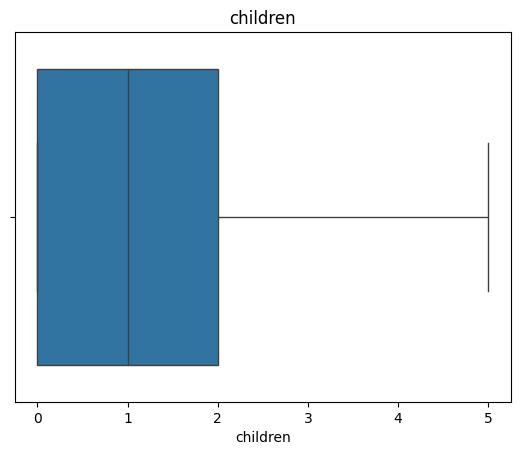

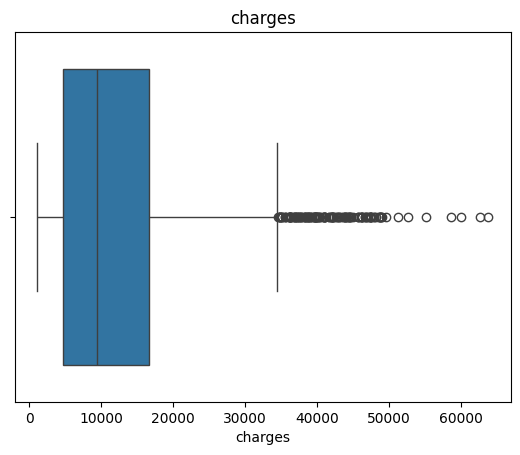

In [34]:
for col in num_cols:
  sns.boxplot(x=df[col])
  plt.title(col)
  plt.show()

In [35]:
numerical_data=df.select_dtypes(include='number')
numerical_data

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


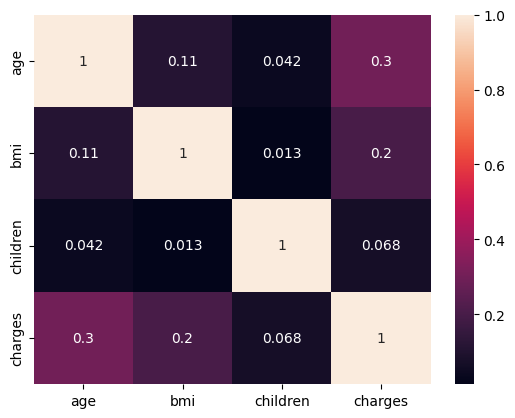

In [84]:
sns.heatmap(numerical_data.corr(), annot=True)
plt.show()

In [85]:
numerical_data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [38]:
# Q1=df['charges'].quantile(0.25)
# Q3=df['charges'].quantile(0.75)
# IQR=Q3-Q1
# lower_limit=Q1-1.5*IQR
# upper_limit=Q3+1.5*IQR
# print(lower_limit)
# print(upper_limit)
# lowerOutlier=df['charges']<lower_limit
# upperOutlier=df['charges']>upper_limit
# outliers=df.loc[lowerOutlier | upperOutlier]
# df=df.loc[~(lowerOutlier | upperOutlier)]
# outliers

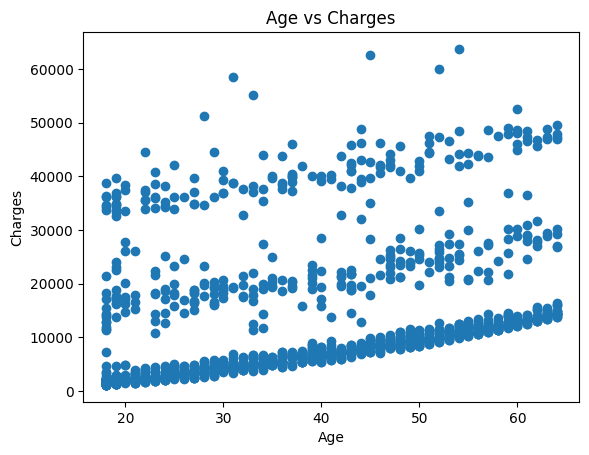

In [54]:
plt.scatter(df['age'], df['charges'])
plt.title('Age vs Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

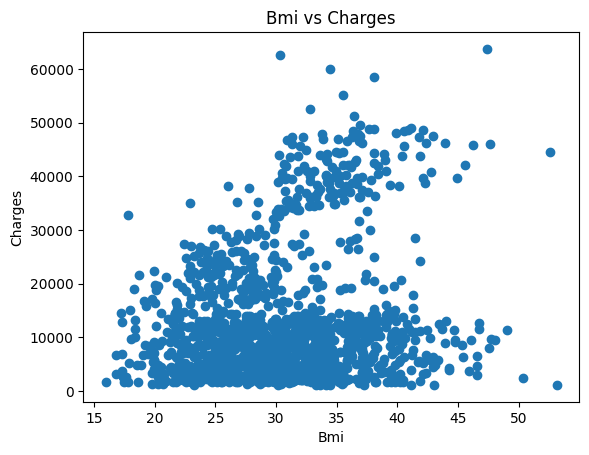

In [40]:
plt.scatter(df['bmi'], df['charges'])
plt.title('Bmi vs Charges')
plt.xlabel('Bmi')
plt.ylabel('Charges')
plt.show()

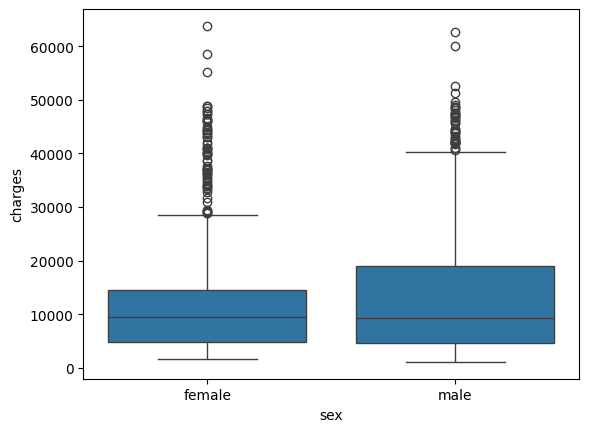

In [107]:
sns.boxplot(x='sex',y='charges',data=df)
plt.show()

In [57]:
df.duplicated().sum()

np.int64(0)

In [56]:
df.drop_duplicates(inplace=True)

In [108]:
df['sex'].isna().sum()

np.int64(0)

In [42]:
df.groupby('smoker')['charges'].mean()

,charges
smoker,
no,8434.268298
yes,32050.231832


In [43]:
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

In [110]:
df['sex_encoded'] = df['sex'].map({'female': 1, 'male': 0})

In [111]:
df['sex_encoded'].unique()

array([1, 0])

In [58]:
df.shape

(1337, 7)

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          1337 non-null   int64  
 1   sex          1337 non-null   object 
 2   bmi          1337 non-null   float64
 3   children     1337 non-null   int64  
 4   smoker       1337 non-null   int64  
 5   region       1337 non-null   object 
 6   charges      1337 non-null   float64
 7   sex_encoded  1337 non-null   int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 94.0+ KB


In [205]:
x=df[['age','smoker','bmi']]
y=df['charges']
x.shape,y.shape

((1337, 3), (1337,))

In [206]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [207]:
scaler = RobustScaler()

X_train[['age', 'bmi']] = scaler.fit_transform(X_train[['age', 'bmi']])
X_test[['age', 'bmi']] = scaler.transform(X_test[['age', 'bmi']])

In [208]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [209]:
model=LinearRegression()
model.fit(X_train_poly,y_train)
print('Slope:',model.coef_)
print('Intercept:',model.intercept_)

Slope: [    0.          6159.69041795 11441.62601768   208.56128809
  1546.72760756  -202.60213819   515.17578801 11441.62601768
 12023.75724542  -646.22757159]
Intercept: 8155.932052442129


In [210]:
y_pred=model.predict(X_test_poly)

comparison=pd.DataFrame({
    'Actual':y_test.values,
    'Predicted':y_pred
})
comparison.head()

,Actual,Predicted
0,8688.85885,10036.020073
1,5708.86700,5660.415904
2,11436.73815,11608.720464
3,38746.35510,35183.977611
4,4463.20510,5674.266585


In [211]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred) * 100


print(f'MAE  = {mae:.3f}')
print(f'MSE  = {mse:.3f}')
print(f'RMSE = {rmse:.3f}')
print(f'R²   = {r2:.3f}')

MAE  = 2814.391
MSE  = 21400305.652
RMSE = 4626.046
R²   = 88.354
